In [2]:
import pandas as pd
import ast
import plotly.express as px

import irina.utility_functions as uf

In [3]:
df_global = pd.read_csv(uf.PATH+"global_cleaned.csv", converters={"author_id": ast.literal_eval,
                                                                  "institution_id": ast.literal_eval,})

In [4]:
df_global[df_global.article_id == "W4386647814"]

,year,article_id,subfield_id,country,author_id,institution_id
3786628,2023,W4386647814,3106,AU,"[A5105825000, A5005193029, A5030779627, A50121...","[I5681781, I5681781, I5681781, I5681781, I5681..."
3786629,2023,W4386647814,3106,CA,[A5015022419],[I185261750]
3786630,2023,W4386647814,3106,CL,[A5056881719],[I162148367]
3786631,2023,W4386647814,3106,DE,"[A5064796035, A5050341450]","[I74656192, I200332995]"
3786632,2023,W4386647814,3106,FR,"[A5100769897, A5104254091]","[I21491767, I4210133362]"
3786633,2023,W4386647814,3106,GB,"[A5038281582, A5100768678]","[I28407311, I1286704778]"
3786634,2023,W4386647814,3106,IL,"[A5065829244, A5039017444]","[I16391192, I174306211]"
3786635,2023,W4386647814,3106,IT,[A5042807344],[I12323705]
3786636,2023,W4386647814,3106,MA,[A5048069343],[I126477371]
3786637,2023,W4386647814,3106,PL,[A5074276926],[I686019]


In [5]:
df_count_authors = (
    df_global
    .groupby(["article_id", "subfield_id"], as_index=False)
    .author_id
    .sum()
    .assign(authors_count = lambda df: [len(auth_list) for auth_list in df.author_id])
)

In [6]:
df_count_countries = (
    df_global
    .groupby(["article_id", "subfield_id"], as_index=False)
    .country
    .agg(list)
    .assign(countries_count = lambda df: [len(c_list) for c_list in df.country])
)
df_count_countries

,article_id,subfield_id,country,countries_count
0,W1002605256,3308,[PL],1
1,W100375260,1208,[ES],1
2,W1008419420,3304,[PL],1
3,W100964016,1212,[CL],1
4,W101184624,2739,[FR],1
...,...,...,...,...
4728490,W996540043,2000,[GB],1
4728491,W99663802,3304,[ES],1
4728492,W997577341,2209,[PL],1
4728493,W999773664,2608,[CN],1


In [7]:
df_count_authors_subfields =(
    df_count_authors
    .merge(uf.df_topics[["subfield_id", "subfield_name", "field_name", "domain_name"]].drop_duplicates(),
           on=["subfield_id"], how="left")
)
df_count_countries_subfields = (
    df_count_countries
    .merge(uf.df_topics[["subfield_id", "subfield_name", "field_name", "domain_name"]].drop_duplicates(),
           on=["subfield_id"], how="left")
)

In [8]:
subfield_name = "Nuclear and High Energy Physics"
px.histogram((
        df_count_authors_subfields
        .sort_values("authors_count", ascending=False)
        .query("subfield_name == @subfield_name")
        # .groupby(["subfield_id", "subfield_name", "field_name", "domain_name"], as_index=False)
        # .authors_count
        # .median()
), x="authors_count", title=f"Number of authors distribution in {subfield_name}", nbins=30)

In [9]:
subfield_name = "Nuclear and High Energy Physics"
(
        df_count_authors_subfields
        .groupby(["subfield_id", "subfield_name", "field_name", "domain_name"], as_index=False)
        .authors_count
        .mean()
).query("subfield_name == @subfield_name")

,subfield_id,subfield_name,field_name,domain_name,authors_count
202,3106,Nuclear and High Energy Physics,Physics and Astronomy,Physical Sciences,10.077368


In [10]:
px.box(
    (
        df_count_authors_subfields.sort_values("authors_count")
        .groupby(["subfield_id", "subfield_name", "field_name", "domain_name"], as_index=False)
        .authors_count
        .mean()
    ),
    points="all",
    x="domain_name",
    y="authors_count",
    color="domain_name",
    hover_data=["subfield_id", "subfield_name", "field_name", "domain_name"],
    title="Mean (by fields) number of authors in collaboration"
)

In [11]:
domain = "Social Sciences"
px.box(
    (
        df_count_authors_subfields
        .query(f"domain_name == @domain")
        # .sort_values("authors_count")
        .groupby(["subfield_id", "subfield_name", "field_name", "domain_name"], as_index=False)
        .authors_count
        .median()
    ),
    points=False,
    x="field_name",
    y="authors_count",
    color="field_name",
    hover_data=["subfield_id", "subfield_name", "field_name", "domain_name"],
    title="Number of authors in collaboration"
)

In [12]:
px.histogram(
    (
        df_count_countries_subfields
        .groupby(["subfield_id", "subfield_name", "field_name", "domain_name"], as_index=False)
        .countries_count
        .mean()
    )
)

ValueError: Plotly Express cannot process wide-form data with columns of different type.

In [11]:
px.box(
    (
        df_count_countries_subfields
        .groupby(["subfield_id", "subfield_name", "field_name", "domain_name"], as_index=False)
        .countries_count
        .mean()
    ),
    points="all",
    x="domain_name",
    y="countries_count",
    color="domain_name",
    hover_data=["subfield_id", "subfield_name", "field_name", "domain_name"],
    title="Mean (by fields) number of countries in collaboration"
)

In [12]:
domain = "Physical Sciences"
px.box(
    (
        df_count_countries_subfields
        .query(f"domain_name == @domain")
        .groupby(["subfield_id", "subfield_name", "field_name", "domain_name"], as_index=False)
        .countries_count
        .mean()
    ),
    points=False,
    x="field_name",
    y="countries_count",
    color="field_name",
    hover_data=["subfield_id", "subfield_name", "field_name", "domain_name"],
    title="Mean (by fields) number of countries in collaboration"
)

In [28]:
df_country_authors = (
    df_global
    .assign(authors_count=lambda df: [len(a) for a in df.author_id])
    .groupby("country", as_index=False)
    .authors_count
    .mean()
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2", how="left")
)

In [13]:
# df_country_unique_authors = (
#     df_global
#     .groupby("country", as_index=False)
#     .author_id
#     .sum()
#     .assign(authors_unique_count=lambda df: [len(set(a)) for a in df.author_id])
# )

In [30]:
df_country_authors

,country,authors_count,alpha-2,alpha-3
0,AD,1.441176,AD,AND
1,AE,2.303000,AE,ARE
2,AF,2.043057,AF,AFG
3,AG,2.220619,AG,ATG
4,AL,2.079627,AL,ALB
...,...,...,...,...
212,WS,1.826087,WS,WSM
213,YE,1.742391,YE,YEM
214,ZA,2.407163,ZA,ZAF
215,ZM,2.646241,ZM,ZMB


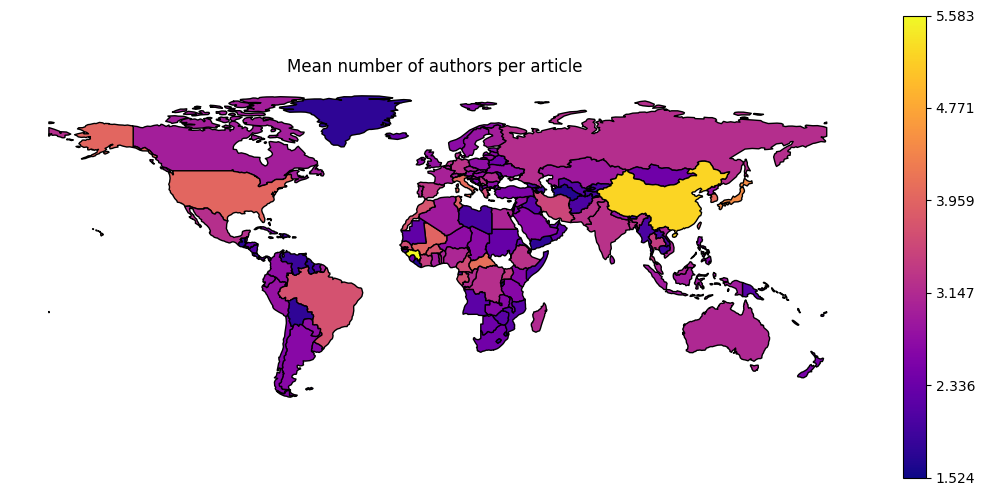

In [34]:
_, _ = uf.plot_map_continuous(df_country_authors, "authors_count", title="Mean number of authors per article")